# Sensibilidad al a?o inicial para `dry spells` (filtro Mar-Nov)

Este notebook rehace el an?lisis para que sea consistente con la discusi?n de `dry spells`:

- Usa rachas secas (`dry spells`) en vez de solo `d?as secos por a?o`.
- Aplica filtro estacional **Marzo-Noviembre**.
- Asigna cada racha al **a?o en que comienza** (`filter_type = "start"`).
- Eval?a tres m?tricas anuales: **promedio de duraci?n**, **`tL`** y **`t99`**.
- Consolida resultados en **4 regiones** de Chile.
- Hace mapas de sensibilidad para la **grilla completa de La Araucan?a**.


In [1]:
import unicodedata
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import linregress
from shapely.geometry import Point
from shapely.prepared import prep

# ------------------------------
# Configuraci?n general
# ------------------------------
DRY_THRESHOLD_MM = 1.0
SEASON_MONTH_MIN = 3
SEASON_MONTH_MAX = 11
FILTER_TYPE = "start"  # Usamos el mes en que COMIENZA la racha
YEARS = np.arange(1979, 2022)
SENSITIVITY_START_YEARS = np.arange(1979, 2001)
MAP_START_YEARS = [1979, 1985, 1990]
MIN_YEARS_FOR_TREND = 10
MIN_SPELLS_FOR_STATS = 5
MIN_SPELLS_FOR_TL = 10

REGION_SPECS = {
    "Coquimbo": {"query": "Coquimbo", "color": "firebrick"},
    "O'Higgins": {"query": "higgins", "color": "darkorange"},
    "La Araucan?a": {"query": "araucan", "color": "forestgreen"},
    "Los Lagos": {"query": "los lagos", "color": "steelblue"},
}

METRIC_LABELS = {
    "mean": "Promedio de duraci?n",
    "tL": "Cutoff tL",
    "t99": "Percentil 99 (t99)",
}

MAP_LIMITS = {
    "mean": (-0.25, 0.25),
    "tL": (-150, 150),
    "t99": (-2.5, 2.5),
}


In [2]:
# ------------------------------
# Carga de datos y funciones auxiliares
# ------------------------------
pr_dir = Path("pr")
files = sorted(pr_dir.glob("CR2MET_pr_v2.5_day_*.nc"))
print("Archivos encontrados:", len(files))
if not files:
    raise RuntimeError("No se encontraron archivos CR2MET en pr/")

ds = xr.open_mfdataset(
    [str(p) for p in files],
    combine="by_coords",
    parallel=True,
    chunks={"time": 365},
)

shape_reader = shpreader.Reader(
    shpreader.natural_earth(
        resolution="10m",
        category="cultural",
        name="admin_1_states_provinces",
    )
)
CHILE_REGION_RECORDS = [r for r in shape_reader.records() if r.attributes.get("admin") == "Chile"]


def normalize_text(text):
    text = str(text).lower()
    text = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in text if not unicodedata.combining(ch))


def get_region_record(query):
    query_norm = normalize_text(query)
    for record in CHILE_REGION_RECORDS:
        name_norm = normalize_text(record.attributes.get("name", ""))
        if query_norm in name_norm:
            return record
    raise ValueError(f"No se encontr? una regi?n chilena que coincida con: {query}")


def annual_metrics_from_durations(durations):
    durations = np.asarray(durations, dtype=float)
    durations = durations[durations > 0]
    n_spells = int(durations.size)

    if n_spells < MIN_SPELLS_FOR_STATS:
        return {
            "mean": np.nan,
            "tL": np.nan,
            "t99": np.nan,
            "n_spells": n_spells,
        }

    mean_dur = float(np.mean(durations))
    t99 = float(np.percentile(durations, 99))
    tL = np.nan

    if n_spells >= MIN_SPELLS_FOR_TL and np.max(durations) > np.min(durations):
        try:
            bins = np.logspace(np.log10(np.min(durations)), np.log10(np.max(durations)), 15)
            counts, bin_edges = np.histogram(durations, bins=bins, density=True)
            bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
            valid_bins = counts > 0
            if np.sum(valid_bins) >= 3:
                Y = np.log(counts[valid_bins])
                X = np.column_stack(
                    (
                        np.ones(np.sum(valid_bins)),
                        np.log(bin_centers[valid_bins]),
                        bin_centers[valid_bins],
                    )
                )
                c, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
                tL = float(-1.0 / c[2]) if c[2] < 0 else np.nan
        except Exception:
            tL = np.nan

    return {
        "mean": mean_dur,
        "tL": tL,
        "t99": t99,
        "n_spells": n_spells,
    }


region_cache = {}


def subset_region_precip(record):
    region_name = record.attributes["name"]
    if region_name in region_cache:
        return region_cache[region_name]

    geom = record.geometry
    min_lon, min_lat, max_lon, max_lat = geom.bounds
    lat_slice = slice(max_lat, min_lat) if ds.lat[0] > ds.lat[-1] else slice(min_lat, max_lat)
    lon_slice = slice(min_lon, max_lon) if ds.lon[0] < ds.lon[-1] else slice(max_lon, min_lon)

    pr_region = (
        ds["pr"]
        .sel(lat=lat_slice, lon=lon_slice)
        .sel(time=slice("1979-01-01", "2021-12-31"))
        .astype("float32")
        .load()
    )

    lon2d, lat2d = np.meshgrid(pr_region["lon"].values, pr_region["lat"].values)
    prepared_geom = prep(geom)
    region_mask = np.array(
        [
            prepared_geom.contains(Point(lon, lat)) or geom.touches(Point(lon, lat))
            for lat, lon in zip(lat2d.ravel(), lon2d.ravel())
        ],
        dtype=bool,
    ).reshape(lat2d.shape)

    region_cache[region_name] = {
        "record": record,
        "pr": pr_region,
        "mask": region_mask,
        "geom": geom,
    }
    return region_cache[region_name]


def collect_pixel_year_durations(pr_region, region_mask):
    vals = pr_region.values
    times = pd.to_datetime(pr_region["time"].values)
    months = times.month
    years = times.year

    per_pixel = {}
    pooled_by_year = {int(year): [] for year in YEARS}

    for i in range(vals.shape[1]):
        for j in range(vals.shape[2]):
            if not region_mask[i, j]:
                continue

            pr_series = vals[:, i, j]
            if np.isnan(pr_series).all():
                continue

            dry_bool = pr_series < DRY_THRESHOLD_MM
            if not np.any(dry_bool):
                continue

            x = np.r_[False, dry_bool, False]
            dx = np.diff(x.astype(int))
            starts = np.where(dx == 1)[0]
            ends = np.where(dx == -1)[0]
            durations = ends - starts

            valid = durations > 0
            starts = starts[valid]
            ends = ends[valid]
            durations = durations[valid]

            if FILTER_TYPE == "start":
                ref_months = months[starts]
                ref_years = years[starts]
            else:
                ref_months = months[ends - 1]
                ref_years = years[ends - 1]

            season_mask = (ref_months >= SEASON_MONTH_MIN) & (ref_months <= SEASON_MONTH_MAX)
            ref_years = ref_years[season_mask]
            durations = durations[season_mask]

            pixel_by_year = {int(year): np.array([], dtype=int) for year in YEARS}
            for year in np.unique(ref_years):
                arr = durations[ref_years == year].astype(int)
                pixel_by_year[int(year)] = arr
                pooled_by_year[int(year)].append(arr)

            per_pixel[(i, j)] = pixel_by_year

    pooled_by_year = {
        year: np.concatenate(chunks) if chunks else np.array([], dtype=int)
        for year, chunks in pooled_by_year.items()
    }
    return per_pixel, pooled_by_year


def build_region_annual_df(pooled_by_year):
    rows = []
    for year in YEARS:
        metrics = annual_metrics_from_durations(pooled_by_year[int(year)])
        rows.append({"year": int(year), **metrics})
    return pd.DataFrame(rows)


def compute_sensitivity_trends(annual_df):
    records = []
    for metric in ["mean", "tL", "t99"]:
        for start_year in SENSITIVITY_START_YEARS:
            subset = annual_df[annual_df["year"] >= start_year].dropna(subset=[metric])
            if len(subset) < MIN_YEARS_FOR_TREND:
                trend = np.nan
            else:
                slope, _, _, _, _ = linregress(subset["year"], subset[metric])
                trend = slope * 10.0
            records.append(
                {
                    "metric": metric,
                    "start_year": int(start_year),
                    "trend_days_per_decade": trend,
                }
            )
    return pd.DataFrame(records)


def build_pixel_annual_metrics(per_pixel, template_pr):
    out = np.full(
        (len(YEARS), 3, template_pr.sizes["lat"], template_pr.sizes["lon"]),
        np.nan,
        dtype=np.float32,
    )
    year_to_idx = {int(year): idx for idx, year in enumerate(YEARS)}

    for (i, j), year_dict in per_pixel.items():
        for year, durations in year_dict.items():
            metrics = annual_metrics_from_durations(durations)
            idx = year_to_idx[int(year)]
            out[idx, 0, i, j] = metrics["mean"]
            out[idx, 1, i, j] = metrics["tL"]
            out[idx, 2, i, j] = metrics["t99"]

    return xr.DataArray(
        out,
        coords={
            "year": YEARS,
            "metric": ["mean", "tL", "t99"],
            "lat": template_pr["lat"],
            "lon": template_pr["lon"],
        },
        dims=("year", "metric", "lat", "lon"),
    )


def compute_trend_map(annual_metric_da, metric, start_year):
    subset = annual_metric_da.sel(metric=metric, year=slice(start_year, 2021))
    x_years = subset["year"].values.astype(float)
    out = np.full((subset.sizes["lat"], subset.sizes["lon"]), np.nan, dtype=np.float32)

    for i in range(subset.sizes["lat"]):
        for j in range(subset.sizes["lon"]):
            y_values = subset[:, i, j].values
            valid = np.isfinite(y_values)
            if np.sum(valid) < MIN_YEARS_FOR_TREND:
                continue
            slope = np.polyfit(x_years[valid], y_values[valid], 1)[0]
            out[i, j] = slope * 10.0

    return xr.DataArray(
        out,
        coords={"lat": subset["lat"], "lon": subset["lon"]},
        dims=("lat", "lon"),
    )


Archivos encontrados: 672


C:\Users\elxpa\AppData\Local\Temp\ipykernel_11676\3113148653.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(


In [3]:
# ------------------------------
# Series anuales regionales para 4 regiones
# ------------------------------
region_results = {}
summary_rows = []

for label, spec in REGION_SPECS.items():
    record = get_region_record(spec["query"])
    region_data = subset_region_precip(record)
    per_pixel, pooled_by_year = collect_pixel_year_durations(region_data["pr"], region_data["mask"])
    annual_df = build_region_annual_df(pooled_by_year)
    sensitivity_df = compute_sensitivity_trends(annual_df)

    region_results[label] = {
        "record": record,
        "pr": region_data["pr"],
        "mask": region_data["mask"],
        "geom": region_data["geom"],
        "per_pixel": per_pixel,
        "pooled_by_year": pooled_by_year,
        "annual_df": annual_df,
        "sensitivity_df": sensitivity_df,
        "pixel_count": int(region_data["mask"].sum()),
        "color": spec["color"],
    }

    for metric in ["mean", "tL", "t99"]:
        metric_trends = sensitivity_df[sensitivity_df["metric"] == metric].copy()
        trend_values = metric_trends["trend_days_per_decade"].to_numpy(dtype=float)
        summary_rows.append(
            {
                "region": label,
                "metric": metric,
                "pixels": int(region_data["mask"].sum()),
                "trend_1979": float(metric_trends.loc[metric_trends["start_year"] == 1979, "trend_days_per_decade"].iloc[0]),
                "trend_2000": float(metric_trends.loc[metric_trends["start_year"] == 2000, "trend_days_per_decade"].iloc[0]),
                "min_trend": float(np.nanmin(trend_values)),
                "max_trend": float(np.nanmax(trend_values)),
                "median_trend": float(np.nanmedian(trend_values)),
                "positive_fraction": float(np.nanmean(trend_values > 0)),
            }
        )

summary_df = pd.DataFrame(summary_rows)

for label, result in region_results.items():
    print(f"{label}: {result['pixel_count']} p?xeles CR2MET dentro del pol?gono regional")


Coquimbo: 1407 p?xeles CR2MET dentro del pol?gono regional
O'Higgins: 651 p?xeles CR2MET dentro del pol?gono regional
La Araucan?a: 1401 p?xeles CR2MET dentro del pol?gono regional
Los Lagos: 2065 p?xeles CR2MET dentro del pol?gono regional


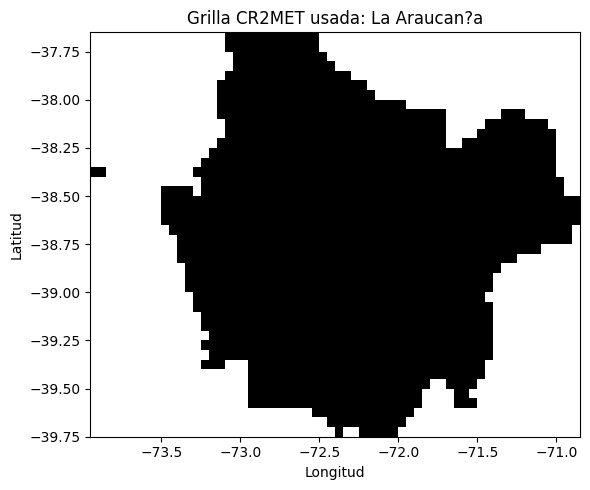

In [4]:
# ------------------------------
# Vista r?pida: m?scara de La Araucan?a
# ------------------------------
araucania = region_results["La Araucan?a"]
mask_da = xr.DataArray(
    araucania["mask"].astype(int),
    coords={"lat": araucania["pr"]["lat"], "lon": araucania["pr"]["lon"]},
    dims=("lat", "lon"),
)

plt.figure(figsize=(6, 5))
plt.pcolormesh(mask_da["lon"], mask_da["lat"], mask_da, shading="auto", cmap="Greys")
plt.title("Grilla CR2MET usada: La Araucan?a")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show()


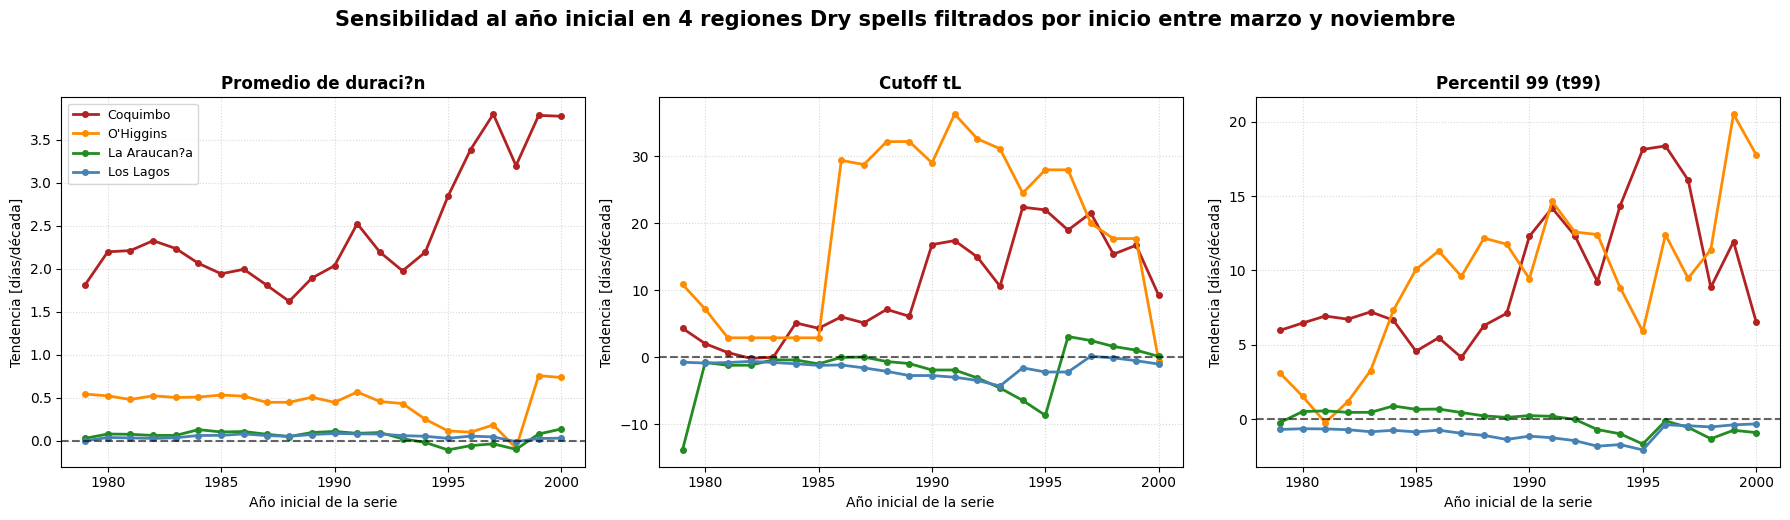

In [11]:
# ------------------------------
# Gr?ficos consolidados de sensibilidad regional
# ------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)
metrics = ["mean", "tL", "t99"]

for ax, metric in zip(axes, metrics):
    for label, result in region_results.items():
        df_plot = result["sensitivity_df"]
        df_plot = df_plot[df_plot["metric"] == metric]
        ax.plot(
            df_plot["start_year"],
            df_plot["trend_days_per_decade"],
            marker="o",
            lw=2,
            ms=4,
            color=result["color"],
            label=label,
        )

    ax.axhline(0, color="black", linestyle="--", alpha=0.6)
    ax.set_title(METRIC_LABELS[metric], fontweight="bold")
    ax.set_xlabel("Año inicial de la serie")
    ax.set_ylabel("Tendencia [días/década]")
    ax.grid(True, linestyle=":", alpha=0.5)

axes[0].legend(loc="best", fontsize=9)
plt.suptitle(
    "Sensibilidad al año inicial en 4 regiones Dry spells filtrados por inicio entre marzo y noviembre",
    fontsize=15,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()
plt.show()


In [13]:
# ------------------------------
# Tabla resumen para las 4 regiones
# ------------------------------
summary_display = summary_df.copy()
for col in ["trend_1979", "trend_2000", "min_trend", "max_trend", "median_trend", "positive_fraction"]:
    summary_display[col] = summary_display[col].round(3)

print(summary_display.to_string(index=False))


      region metric  pixels  trend_1979  trend_2000  min_trend  max_trend  median_trend  positive_fraction
    Coquimbo   mean    1407       1.812       3.773      1.621      3.798         2.195              1.000
    Coquimbo     tL    1407       4.361       9.256     -0.127     22.427         8.214              0.955
    Coquimbo    t99    1407       5.973       6.544      4.152     18.373         7.169              1.000
   O'Higgins   mean     651       0.542       0.735     -0.087      0.756         0.490              0.955
   O'Higgins     tL     651      10.917      -0.514     -0.514     36.322        22.292              0.955
   O'Higgins    t99     651       3.105      17.783     -0.225     20.510         9.839              0.955
La Araucan?a   mean    1401       0.027       0.136     -0.108      0.136         0.074              0.773
La Araucan?a     tL    1401     -13.797       0.162    -13.797      3.128        -0.819              0.318
La Araucan?a    t99    1401      -0.2

In [8]:
# ------------------------------
# M?tricas anuales por p?xel para La Araucan?a
# ------------------------------
araucania_pixel_metrics = build_pixel_annual_metrics(araucania["per_pixel"], araucania["pr"])

trend_maps = {}
for metric in ["mean", "tL", "t99"]:
    trend_maps[metric] = {}
    for start_year in MAP_START_YEARS:
        trend_maps[metric][start_year] = compute_trend_map(araucania_pixel_metrics, metric, start_year)

print("Mapas de tendencia para La Araucan?a listos.")
print("Nota: tL puede mostrar ruido local si la estimaci?n anual es inestable en algunos p?xeles.")


Mapas de tendencia para La Araucan?a listos.
Nota: tL puede mostrar ruido local si la estimaci?n anual es inestable en algunos p?xeles.


C:\Users\elxpa\AppData\Local\Temp\ipykernel_11676\2448235789.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


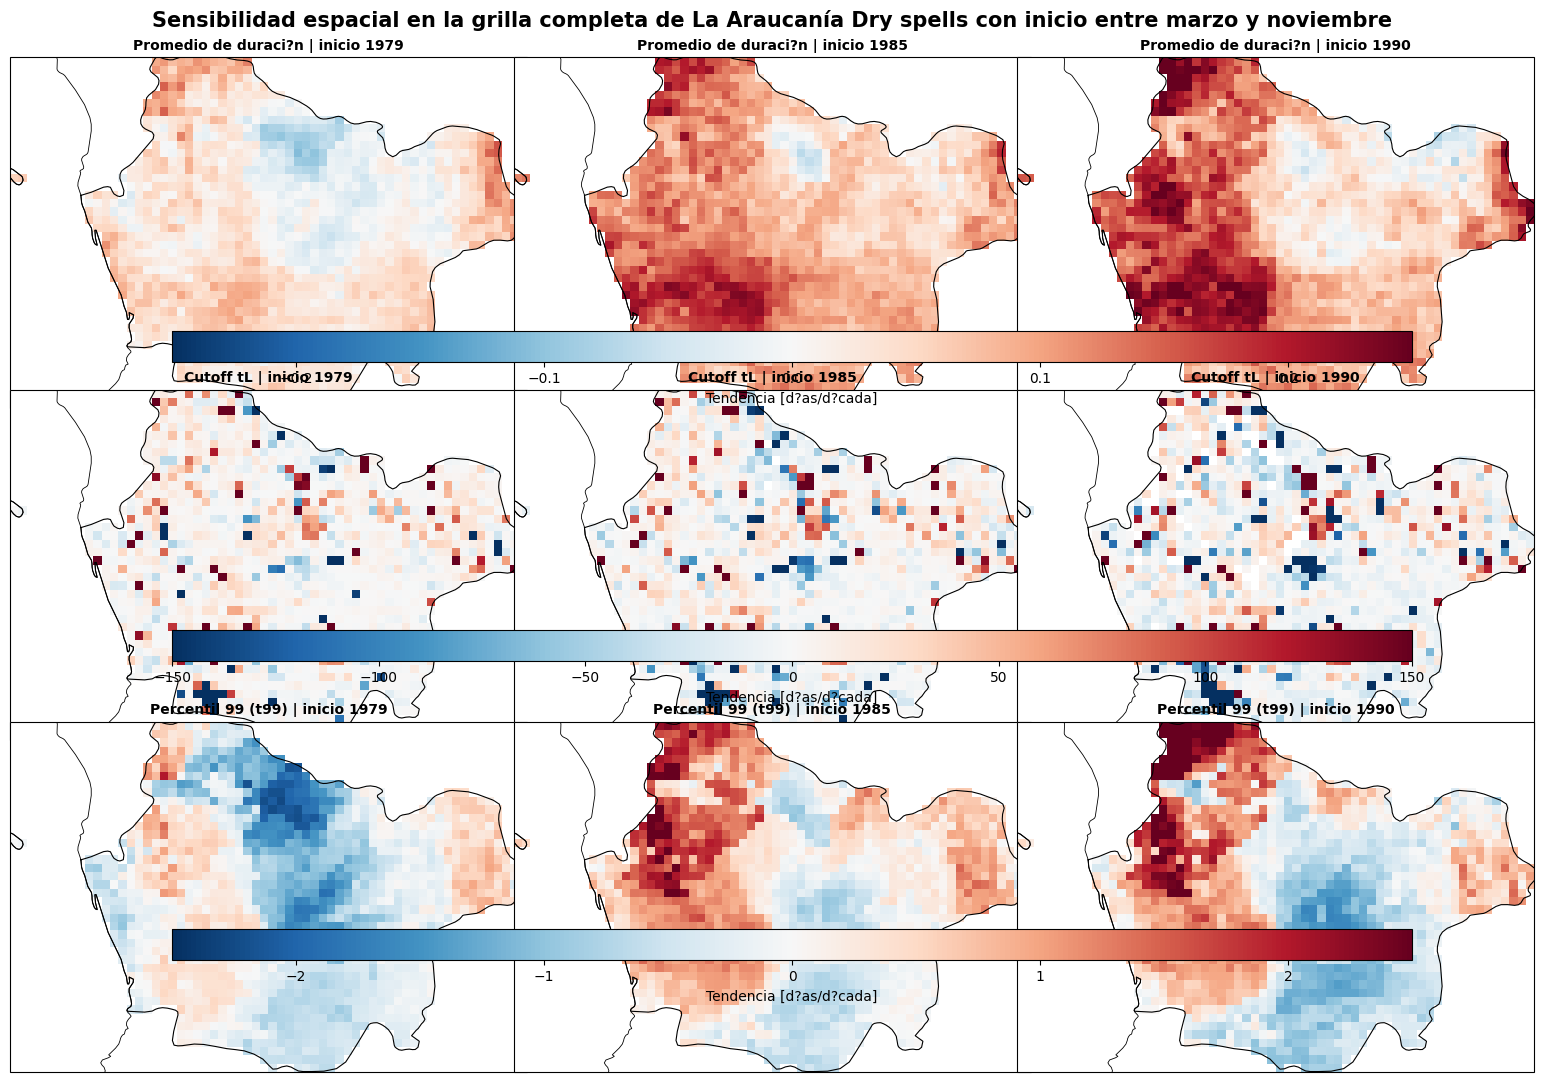

In [10]:
# ------------------------------
# Mapas de sensibilidad para la grilla de La Araucan?a
# ------------------------------
fig, axes = plt.subplots(
    3,
    len(MAP_START_YEARS),
    figsize=(16, 11),
    subplot_kw={"projection": ccrs.PlateCarree()},
    sharex=True,
    sharey=True,
)

metric_order = ["mean", "tL", "t99"]
for row_idx, metric in enumerate(metric_order):
    vmin, vmax = MAP_LIMITS[metric]
    for col_idx, start_year in enumerate(MAP_START_YEARS):
        ax = axes[row_idx, col_idx]
        data = trend_maps[metric][start_year]
        im = data.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False,
        )
        ax.add_geometries(
            [araucania["geom"]],
            crs=ccrs.PlateCarree(),
            facecolor="none",
            edgecolor="black",
            linewidth=0.8,
        )
        ax.coastlines(linewidth=0.6)
        ax.set_title(f"{METRIC_LABELS[metric]} | inicio {start_year}", fontsize=10, fontweight="bold")
        if row_idx == 2:
            ax.set_xlabel("Longitud")
        if col_idx == 0:
            ax.set_ylabel("Latitud")

    cbar = fig.colorbar(im, ax=axes[row_idx, :], orientation="horizontal", pad=0.06, aspect=40)
    cbar.set_label("Tendencia [d?as/d?cada]")

plt.suptitle(
    "Sensibilidad espacial en la grilla completa de La Araucanía Dry spells con inicio entre marzo y noviembre",
    fontsize=15,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()


## Lectura esperada del notebook

- Si una curva se mantiene del mismo signo al cambiar el a?o inicial, la se?al es robusta.
- Si una curva cambia de signo con frecuencia, hay alta sensibilidad al a?o inicial.
- `mean` resume el cambio t?pico en duraci?n.
- `t99` resume el comportamiento de la cola extrema.
- `tL` es ?til, pero suele ser la m?trica m?s inestable porque depende de un ajuste exponencial en la cola.
- En los mapas de La Araucan?a se compara c?mo cambia la tendencia local al iniciar la serie en distintos a?os.
